# Peace River data

The Peace River is a significant contributor of freshwater and associated nutrients to Charlotte Harbor, which subsequently influences coastal waters where red tides occur. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

import geopandas as gpd
import contextily as ctx
from shapely import wkb
from shapely.geometry import Point
from adjustText import adjust_text

import os 
import dataretrieval.nwis as nwis
import requests
from io import StringIO

import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
river='Peace'  #['Peace', 'Caloosahatchee']

## 1. Discharge

### 1.1 Select station close to the Gulf of America

The USGS monitoring station 02296750 at State Road 70 in Arcadia, Florida is ued to understand the Peace River's influence on the Charlotte Harbor estuarine system and red tides in the Gulf of America. It provides long-term discharge and water level data, essential for assessing freshwater inflow, nutrient loading, and salinity—key factors driving red tides. Its location near the river's mouth makes it valuable for studying freshwater-coastal interactions. While other stations, such as 02295637 at Zolfo Springs and 02294898 at Fort Meade, also monitor discharge and water levels, Arcadia’s strategic position and historical data since 1912 make it particularly valuable for studying red tides

For watershed boundary data:   

https://www.usgs.gov/national-hydrography 

https://www.usgs.gov/national-hydrography/access-national-hydrography-products  


For water level data:  
https://chnep.wateratlas.usf.edu/datadownload/

This code reads the flow data to identify stations close to Charlotte Harbour

[None 'Little Charley Bowlegs Creek' 'Cypress Slough' 'Thompson Branch'
 'Oak Creek' 'Fish Branch' 'Punch Gully' 'Lee Branch' 'Charlie Creek'
 'Troublesome Creek' 'Gum Swamp Branch' 'Little Payne Creek'
 'Sweetwater Branch' 'Peace River' 'Honey Run' 'Little Charlie Creek'
 'Old Town Creek' 'Brushy Creek' 'Horse Creek' 'Buckhorn Creek'
 'Cypress Branch' 'Brandy Branch' 'Peace Creek' 'Joshua Creek'
 'Hawthorne Creek' 'Myrtle Slough' 'Broad Creek' 'Parks Creek'
 'Boggy Branch' 'Alligator Branch' 'McCullough Creek' 'Bowlegs Creek'
 'Prairie Creek' 'Lake Dale Branch' 'Hickory Branch' 'Thornton Branch'
 'Peace Creek Drainage Canal' 'Sand Gully' 'Buzzard Roost Branch'
 'Payne Creek' 'Shell Creek' 'Limestone Creek' 'Hickory Creek'
 'Hog Branch' 'Hunter Creek' 'Hampton Branch' 'Shirttail Branch'
 'Sandy Gully' 'Bee Branch' 'Cow Slough' 'Gilshey Branch' 'Deep Creek'
 'Tippen Bay' 'Lettis Creek' 'Doe Branch' 'West Fork Horse Creek'
 'Hickey Branch' 'Max Branch' 'Mossy Gully' 'McBride Branch' 'Lew

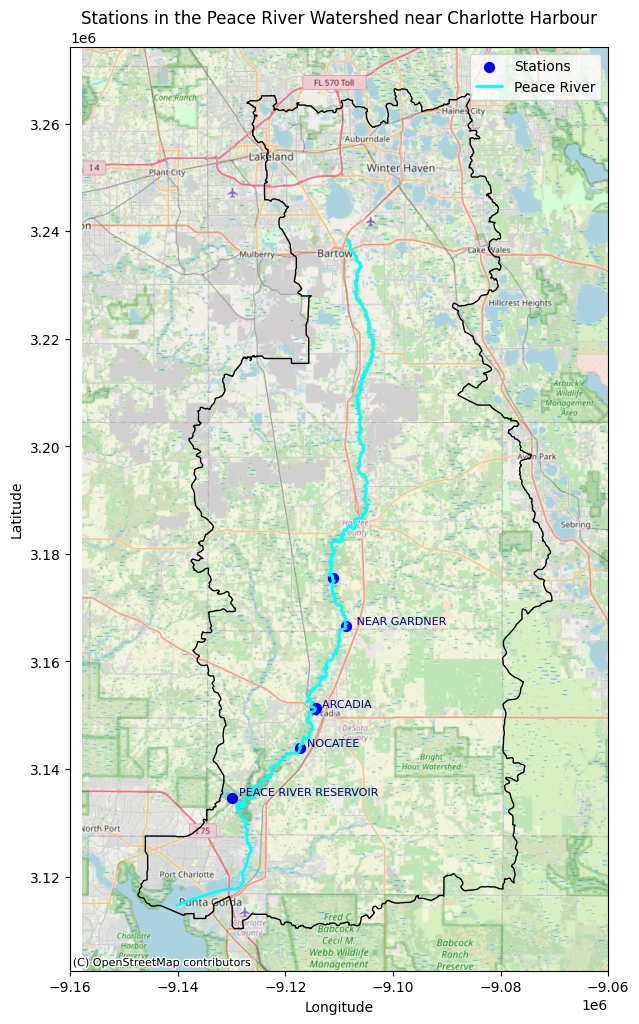

In [2]:
# Load the CSV file (update path if needed)
#file_path = 'input/DataDownload_4344079_row.csv'
#HU=['03100101', '03090205']  #Peace river basin, Caloosahatchee River Basin
#river='Peace'  #['Peace', 'Caloosahatchee']
if river=='Peace':
    basinID='03100101'  #HU of Peace river basin
    lat_lon =[27.5, 26.5, -82.5, -81.5]  # Filter for stations close to the Gulf of Mexico

elif river=='Caloosahatchee':
    basinID='03090205'  #HU of Caloosahatchee River Basin
    lat_lon =[27.5, 26.5, -90, -81.5] # Filter for stations close to the Gulf of Mexico

file_path = f'input/HU8_{basinID}_Flow.csv'

#data = pd.read_csv(file_path)
data = pd.read_csv(file_path, low_memory=False, dtype={'StationID': str, 'Longitude_DD': float})

# Filter the data for Elevation and Flow parameters
filtered_data = data[data['Parameter'].isin(['Level_FT_NAVD88', 'Flow_CFS'])]
filtered_data = filtered_data.dropna(subset=['Latitude_DD', 'Longitude_DD'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    filtered_data, 
    geometry=gpd.points_from_xy(filtered_data['Longitude_DD'], filtered_data['Latitude_DD']),
    crs='EPSG:4326'
)

# Remove duplicates based on station location and name
unique_stations = gdf[['StationName', 'geometry']].drop_duplicates()

# Filter for stations close to the Gulf of Mexico
gulf_stations = unique_stations[
    (unique_stations.geometry.y <= lat_lon[0]) & 
    (unique_stations.geometry.y >= lat_lon[1]) & 
    (unique_stations.geometry.x >= lat_lon[2]) & 
    (unique_stations.geometry.x <= lat_lon[3])
]

# Load the Peace River Watershed shapefile
#NHD_H_03100101_HU8_Shape
watershed = gpd.read_file(f'input/NHD_H_{basinID}_HU8_Shape/WBDHU8.shp')

# Load the NHD flowline data
#e.g, NHD_H_03100101_HU8_Shape
flowlines = gpd.read_file(f'input/NHD_H_{basinID}_HU8_Shape/NHDFlowline.shp')

# Convert to 2D geometry (strip Z values)
flowlines['geometry'] = flowlines['geometry'].apply(
    lambda geom: wkb.loads(wkb.dumps(geom, output_dimension=2))
)

# Filter the flowlines to select only Peace River
print(flowlines['gnis_name'].unique())
if river=='Peace':
    river_to_plot = flowlines[flowlines['gnis_name'].str.strip().str.lower() == 'peace river']
elif river=='Caloosahatchee':
    river_to_plot = flowlines[flowlines['gnis_name'].str.strip() == 'Caloosahatchee River']
    
# Define available basemaps
basemaps = {
    'OpenStreetMap': ctx.providers.OpenStreetMap.Mapnik,
    'CartoDB Positron': ctx.providers.CartoDB.Positron,
    'CartoDB DarkMatter': ctx.providers.CartoDB.DarkMatter,
    'CartoDB Voyager': ctx.providers.CartoDB.Voyager,
    'Esri World Imagery': ctx.providers.Esri.WorldImagery,
    'Esri World Topo Map': ctx.providers.Esri.WorldTopoMap
}

# elect basemap
choice = 1  # 1 = OpenStreetMap
selected_basemap = list(basemaps.values())[choice - 1]

# Plotting
fig, ax = plt.subplots(figsize=(14, 12))

# Plot watershed boundary
watershed.to_crs(epsg=3857).plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)

# Plot the stations near the Gulf of Mexico
gulf_stations.to_crs(epsg=3857).plot(ax=ax, markersize=50, color='blue', label='Stations')

# Add station names:
# - Remove 'Peace River' from labels
# - Plot every second station except the last one


for i, row in enumerate(gulf_stations.to_crs(epsg=3857).iterrows()):
    if river=='Peace':   
        #row[1]['StationName']
        label = row[1]['StationName'].replace('PEACE RIVER AT ', '').\
        replace('PEACE RIVER BELOW CHARLIE CREEK','').replace('FL','')
        if i % 2 == 0 or i == len(gulf_stations) - 1:  # Always show the last station
            ax.text(row[1].geometry.x, row[1].geometry.y, label, 
                    fontsize=8, ha='left', va='bottom', color='darkblue')
    
    elif river=='Caloosahatchee':
        # Strip whitespace and standardize case
        gulf_stations.loc[:, 'StationName'] = gulf_stations['StationName'].str.strip()

        # Add station labels (only for key stations)
        stations_to_label = [
            'CALOOSAHATCHEE RIVER AT S-79, NR.OLGA, FLA',
            'CALOOSAHATCHEE RIVER AT FORT MYERS FL',
            'TOWNSEND CANAL NEAR ALVA,FL',
            'Big Water Control Structure',
            'Twin Ponds'
        ]
        
        # Iterate outside the main loop and add labels only for key stations
        for i, row in gulf_stations.to_crs(epsg=3857).iterrows():
            if row['StationName'] in stations_to_label:
                label = row['StationName']
                ax.text(
                    row.geometry.x*0.9998, 
                    row.geometry.y*1.0001, 
                    label, 
                    fontsize=8, 
                    ha='left', 
                    va='bottom', 
                    color='darkblue'
                )

# Plot the Peace River
river_to_plot.to_crs(epsg=3857).plot(ax=ax, color='cyan', label=f'{river} River', linewidth=2)


# Add selected basemap (lower resolution for faster rendering)
ctx.add_basemap(ax, source=selected_basemap, zoom=10) 

# Fix x-axis label crowding (reduce number of ticks)
ax.set_xticks(ax.get_xticks()[::2])  # Show every second tick to reduce clutter

# Customize plot
plt.title(f'Stations in the {river} River Watershed near Charlotte Harbour', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

# Create 'figures' folder if it does not exist
if not os.path.exists('figures'):
    os.makedirs('figures')

# Save figure
plt.savefig(f'figures/{river}_river_Fig1_stations.png', dpi=300)

plt.show()

In peace river: The discharge data from USGS station 02296750 represents the daily streamflow measurements for the Peace River at Arcadia, Florida in cubic feet per second (cfs). The data spans from October 1, 1985, to the present, capturing seasonal variations, storm events, and long-term hydrological trends. The station is part of the USGS National Water Information System (NWIS), which follows standardized methods for data collection and processing. However, the data may contain uncertainties due to factors such as instrument calibration errors, changes in channel geometry, flow estimation methods, and environmental factors like debris or vegetation influencing water flow. The data is marked with an approval code ('A'), indicating that it has been quality-checked and meets USGS data accuracy standards. However, for future study we need to account for measurement errors by learning about the error and distribution and missing data through using a physics-based model.

In [3]:
gulf_stations.to_crs(epsg=3857)

,StationName,geometry
8434,PEACE RIVER AT ARCADIA,POINT (-9114447.195 3151110.015)
12434,PEACE RIVER AT ARCADIA FL,POINT (-9114385.366 3151269.161)
114009,PEACE RIVER AT NOCATEE FL,POINT (-9117261.205 3143829.886)
118348,PEACE RIVER AT PEACE RIVER RANCH NR BUCHANAN FL,POINT (-9111231.262 3175561.422)
170068,PEACE RIVER BELOW CHARLIE CREEK NEAR GARDNER FL,POINT (-9108788.354 3166507.751)
195994,PEACE RIVER RESERVOIR,POINT (-9129846.392 3134692.433)


#### Key Stations in the Peace River Watershed  

The most important station for red tide prediction in the Peace River Watershed is PEACE RIVER AT ARCADIA. This station is strategically located on the mainstem of the Peace River near Arcadia, providing long-term data on freshwater discharge and nutrient loading into Charlotte Harbor. Discharge from this station directly influences the nutrient budget of Charlotte Harbor, which in turn affects red tide development along the Gulf Coast. High discharge events at this station are closely linked to increased nutrient input (particularly nitrogen and phosphorus) into the coastal ecosystem, which can fuel Karenia brevis blooms. The station’s long historical record and direct connection to coastal inflow make it critical for red tide prediction and monitoring.  Other relevant stations that could improve model performance or provide additional context for understanding nutrient dynamics include:  

- PEACE RIVER AT NOCATEE FL: This station is located downstream of the Arcadia station, closer to Charlotte Harbor. It provides insights into how nutrient loading and discharge from Arcadia propagate downstream, influencing nutrient delivery into the estuary.  
- PEACE RIVER BELOW CHARLIE CREEK NEAR GARDNER FL: This station captures discharge and nutrient inputs from Charlie Creek, a key tributary of the Peace River. While not directly influencing the estuary, nutrient inputs from Charlie Creek could contribute to red tide severity under high flow conditions.  
- PEACE RIVER RESERVOIR: The reservoir can influence downstream flow and nutrient concentrations through water retention and controlled releases. While its direct impact on nutrient delivery to Charlotte Harbor is limited, it may be useful for understanding flow regulation and its downstream effects on nutrient loading.  
- PEACE RIVER AT PEACE RIVER RANCH NEAR BUCHANAN FL: This upstream station provides data on freshwater and nutrient sources further up the watershed. While it has limited direct influence on coastal nutrient loading, it may help explain the seasonal patterns of nutrient transport along the Peace River.


### 1.2 Downloading data

In [4]:
download_data = False #Set to True if you want to download the data
site='arcadia'

if download_data:
    # # Define station ID and parameter for discharge
    # site = '02297100'  # Nocatee, FL station ID
    # parameter = '00060'  # Discharge in cfs
    # start_date = '1985-01-01'
    # end_date = '2025-01-01'
    #https://waterservices.usgs.gov/nwis/iv/?format=json&sites=02296750&parameterCd=00060&startDT=1985-01-01&endDT=2025-01-01
    
    # Site number and parameter code for discharge (00060)
    site = '02296750'
    parameter = '00060'
    start_date = '1985-01-01'
    end_date = '2025-01-01'
    
    # Retrieve data
    df = nwis.get_record(sites=site, parameterCd=parameter, start=start_date, end=end_date)
    
    # Display data
    df
    
    # Save to CSV
    df.to_csv('input/{river_river_discharge_{site}.csv', index=True)
    

### 1.3 Plot discharge

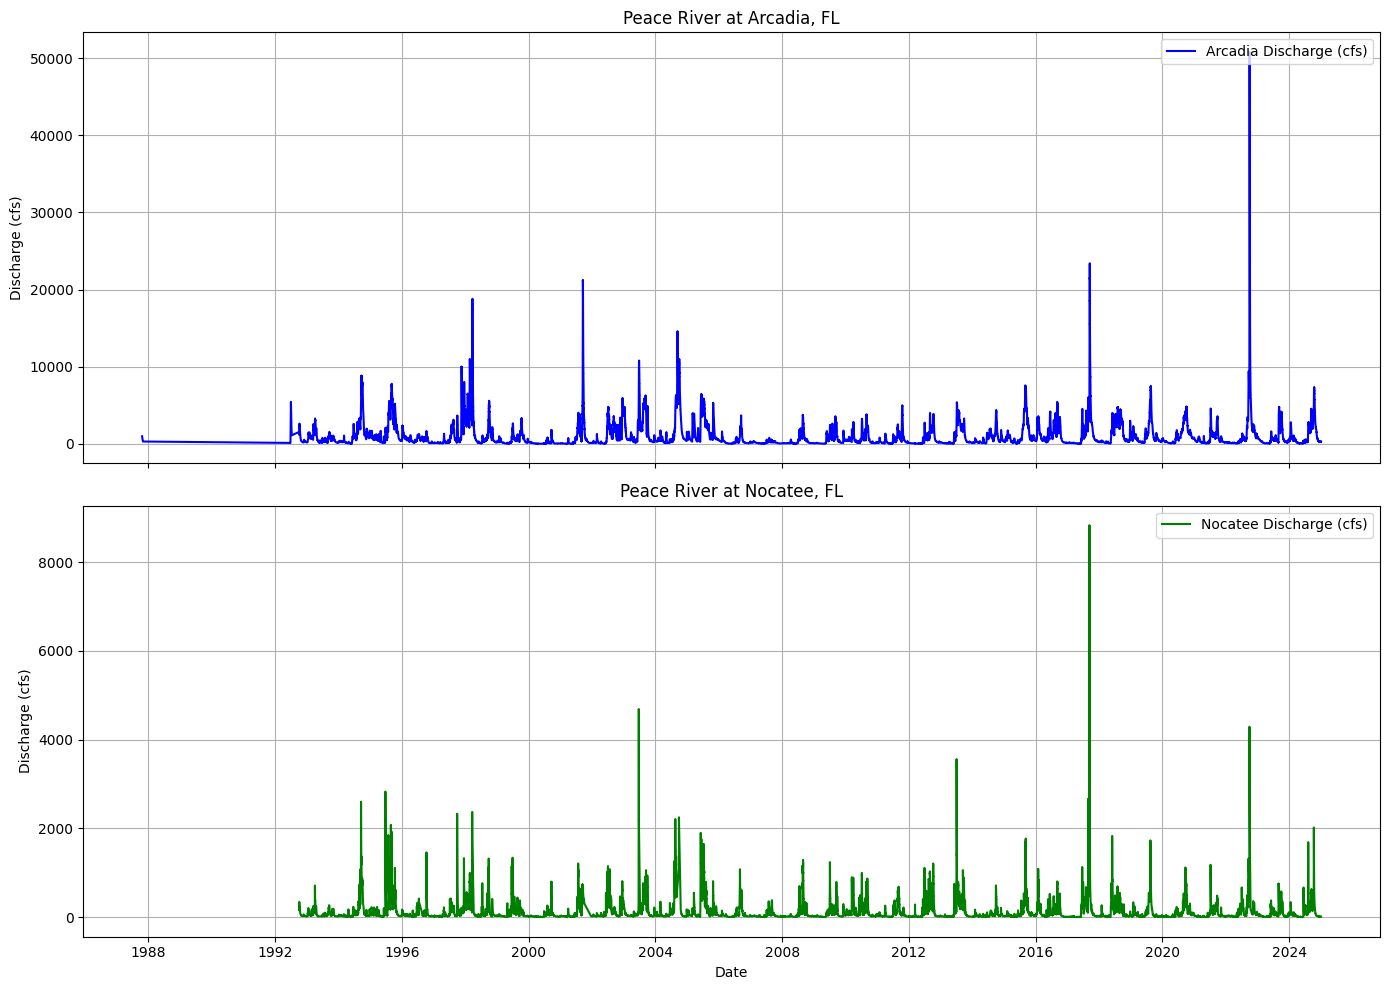

In [5]:
# Load the discharge data for both Arcadia and Nocatee from CSV files
file_arcadia = 'input/peace_river_discharge_arcadia.csv'
file_nocatee = 'input/peace_river_discharge_nocatee.csv'

# Read data files
discharge_arcadia = pd.read_csv(file_arcadia)
discharge_nocatee = pd.read_csv(file_nocatee)

# Convert 'datetime' columns to datetime format
discharge_arcadia['datetime'] = pd.to_datetime(discharge_arcadia['datetime'])
discharge_nocatee['datetime'] = pd.to_datetime(discharge_nocatee['datetime'])

# Create subplots for Arcadia and Nocatee
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot for Arcadia
axs[0].plot(discharge_arcadia['datetime'], discharge_arcadia['00060'], label='Arcadia Discharge (cfs)', color='blue')
axs[0].set_ylabel('Discharge (cfs)')
axs[0].set_title('Peace River at Arcadia, FL')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Plot for Nocatee
axs[1].plot(discharge_nocatee['datetime'], discharge_nocatee['00060'], label='Nocatee Discharge (cfs)', color='green')
axs[1].set_ylabel('Discharge (cfs)')
axs[1].set_title('Peace River at Nocatee, FL')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Set common x-label
plt.xlabel('Date')

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'figures/{river}_river_Fig2_discharge.png')
# Display the plot
plt.show()

Arcadia station (USGS 02296750) records higher flow rates compared to the Nocatee station (USGS 02297100). This discrepancy arises because the Arcadia station monitors the main stem of the Peace River, capturing cumulative flow from a larger upstream drainage area, whereas the Nocatee station measures discharge from Joshua Creek, a smaller tributary within the Peace River Basin. For studying red tides in the Gulf of Mexico, discharge data from the Arcadia station is more pertinent. Monitoring at Arcadia provides a comprehensive understanding of the total freshwater inflow and nutrient loads entering the estuarine and coastal systems.

## 2. Nutrients

### 2.1 Nurtient data

The Total Nitrogen (TN) and Total Phosphorus (TP) data for the Peace River Basin were obtained from the Water Atlas, which serves as a central repository for water quality, hydrology, and environmental data across various Florida watersheds. The Peace River Basin, located in southwest Florida, is a vital waterway that supports both ecological and human needs, including municipal water supply, agriculture, and recreation. The basin is highly influenced by natural and anthropogenic factors, including urban development, agricultural runoff, and phosphate mining, which contribute to nutrient loading and water quality issues such as eutrophication and harmful algal blooms (HABs). The Water Atlas compiles data from multiple sources, including the Southwest Florida Water Management District (SWFWMD), the Florida Department of Environmental Protection (FDEP), and local environmental agencies. To access TN and TP data for the segment of the Peace River near the Gulf of Mexico we focus on:
- Peace River (CHNEP): This segment falls under the jurisdiction of the Coastal & Heartland National Estuary Partnership (CHNEP) and encompasses areas closer to the river's mouth near the Gulf.
- Peace River Estuary (Upper Segment North) (CHNEP): This section includes the upper portion of the estuary where the Peace River transitions into tidal waters as it approaches the Gulf.
- Tidal Peace River (CHNEP): This segment covers the tidal sections of the Peace River within the CHNEP's monitoring area, reflecting the river's interaction with Gulf tides.

By selecting these segments, we obtain TN and TP data relevant to the lower reaches of the Peace River near its confluence with the Gulf of Mexico.

Data information: https://chnep.wateratlas.usf.edu/waterbodies/basins/7/peace-river-basin

Data information: https://chnep.wateratlas.usf.edu/waterbodies/basins/1/caloosahatchee-river-basin 

Data download: https://chnep.wateratlas.usf.edu/datadownload/Default.aspx

#### Data source values
- `USGS_NWIS` – USGS National Water Information System – A comprehensive database of surface water, groundwater, and water quality data collected by the U.S. Geological Survey (USGS).  
- `LEGACYSTORET_21FLA` – Legacy STORET data from Florida – Historical water quality data stored in the legacy version of the STORET database maintained by the EPA.  
- `LEGACYSTORET_1113S000` – Legacy STORET data from Florida – Historical data from a specific Florida station stored in the legacy STORET database.  
- `LEGACYSTORET_21FLSWFD` – Legacy STORET data from the Southwest Florida Water Management District – Historical data stored in the legacy STORET database collected in the Southwest Florida region.  
- `STORET_21FLPOLK` – STORET data from Polk County, Florida – Modern STORET data from water quality monitoring stations in Polk County.  
- `POLKCO_NRD_WQ` – Polk County Natural Resources Department – Water Quality – Data collected specifically by Polk County's water quality monitoring programs.  
- `STORET_FLPRMRWS` – STORET data from the Peace River Manasota Regional Water Supply Authority – Data collected from water supply and quality monitoring stations in the Peace River basin.  
- `STORET_21FLSWFD` – STORET data from the Southwest Florida Water Management District – Data collected from water quality monitoring stations in Southwest Florida.  
- `LEGACYSTORET_21FLGW` – Legacy STORET groundwater data from Florida – Historical groundwater data stored in the legacy STORET database.  
- `STORET_SWFMDDEP` – STORET data from the Southwest Florida Water Management District submitted to the Florida Department of Environmental Protection (DEP).  
- `STORET_21FLGW` – STORET groundwater data from Florida – Modern groundwater data collected under the STORET system.  
- `STORET_21FLFTM` – STORET data from Fort Myers, Florida – Modern STORET data collected from water quality monitoring stations in Fort Myers.  
- `STORET_21FLTPA` – STORET data from Tampa, Florida – Modern STORET data collected from water quality monitoring stations in the Tampa area.  
- `LAKEWATCH_V` – Florida LAKEWATCH – A volunteer-based water quality monitoring program managed by the University of Florida that focuses on lakes.  
- `WIN_21FLMOSA` – WIN (Watershed Information Network) data from Mosaic – Data from Mosaic-operated monitoring stations under the WIN program.  
- `STORET_21FLWQSP` – STORET data from Florida water quality monitoring stations – Data from various Florida monitoring stations collected under the STORET system.  
- `WIN_21FLSWFD` – WIN data from the Southwest Florida Water Management District – WIN data collected from monitoring stations in Southwest Florida.  
- `WIN_FLPRMRWS` – WIN data from the Peace River Manasota Regional Water Supply Authority – Data from the Peace River basin under the WIN program.  
- `WIN_21FLTPA` – WIN data from Tampa, Florida – Data from monitoring stations in the Tampa area under the WIN program.  
- `WIN_21FLWQA` – WIN data from Florida water quality monitoring – WIN data from statewide water quality monitoring stations.  
- `WIN_21FLGW` – WIN groundwater data from Florida – Groundwater data collected under the WIN program.  
- `WIN_21FLPOLK` – WIN data from Polk County, Florida – Data collected from monitoring stations in Polk County under the WIN program.  
- `WIN_21FLFTM` – WIN data from Fort Myers, Florida – Data from monitoring stations in Fort Myers under the WIN program.  
- `WIN_21FLCHCO` – WIN data from Charlotte County, Florida – Data from monitoring stations in Charlotte County under the WIN program.

#### QA code values
- `NaN` – No QA code assigned  
- `E` – Estimated value  
- `<` – Below detection limit  
- `A` – Acceptable  
- `J` – Estimated value (within detection limit but uncertain)  
- `Q` – Questionable data  
- `+` – Added value during processing  
- `Q+` – Questionable but added value  
- `Y` – Lab analysis confirmation  
- `Y+` – Confirmed but added value  
- `QY` – Questionable lab-confirmed value  
- `V` – Verified value  
- `AJ` – Acceptable but estimated value  
- `U` – Not detected (below detection limit)  

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Actual_StationID,Actual_Latitude,Actual_Longitude,DEP_WBID,SampleDate,...,DepthUnits,Parameter,Characteristic,Sample_Fraction,Result_Value,Result_Unit,QACode,Result_Comment,Original_Result_Value,Original_Result_Unit
0,300115,Arcadia Canal,WIN_21FLGW,56590,Z4-SS-13040 UNNAMED SMALL STREAM,56590,27.209207,-81.858291,1623C,2019-08-06,...,m,TP_ugl,Phosphorus as P,Total,360.0,ug/l,NaN,NaN,0.36,mg/L
1,300115,Arcadia Canal,WIN_21FLGW,56590,Z4-SS-13040 UNNAMED SMALL STREAM,56590,27.209207,-81.858291,1623C,2019-08-06,...,m,TN_ugl,Nitrogen,Total,1490.0,ug/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN
2,300106,Barber Branch,WIN_21FLSWFD,700356,Barber Branch nr Homeland,700356,27.838333,-81.812222,1623J,2017-10-02,...,m,TN_ugl,Nitrogen,Total,990.0,ug/l,NaN,NaN,0.99,mg/L
3,300106,Barber Branch,WIN_21FLSWFD,700356,Barber Branch nr Homeland,700356,27.838333,-81.812222,1623J,2017-10-02,...,m,TP_ugl,Phosphorus as P,Total,2150.0,ug/l,NaN,NaN,2.15,mg/L
4,300106,Barber Branch,WIN_21FLSWFD,700356,Barber Branch nr Homeland,700356,27.838333,-81.812222,1623J,2017-12-11,...,m,TN_ugl,Nitrogen,Total,800.0,ug/l,NaN,NaN,0.80,mg/L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11536,9000307,Peace River Estuary (Upper Segment North),WIN_21FLCHCO,MC2056E05,Deep Creek near Santos Drive,MC2056E05,27.025220,-82.000690,2056C1,2024-03-26,...,m,TP_ugl,Phosphorus as P,Total,130.0,ug/l,NaN,NaN,0.13,mg/L
11537,9000307,Peace River Estuary (Upper Segment North),WIN_21FLCHCO,MC2056E05,Deep Creek near Santos Drive,MC2056E05,27.025220,-82.000690,2056C1,2024-04-16,...,m,TP_ugl,Phosphorus as P,Total,110.0,ug/l,NaN,NaN,0.11,mg/L
11538,9000307,Peace River Estuary (Upper Segment North),WIN_21FLCHCO,MC2056E05,Deep Creek near Santos Drive,MC2056E05,27.025220,-82.000690,2056C1,2024-04-16,...,m,TN_ugl,Nitrogen,Total,740.0,ug/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN
11539,9000307,Peace River Estuary (Upper Segment North),WIN_21FLCHCO,MC2056E05,Deep Creek near Santos Drive,MC2056E05,27.025220,-82.000690,2056C1,2024-05-21,...,m,TN_ugl,Nitrogen,Total,990.0,ug/l,NaN,Water Institute Calculated: TKN + NOx,NaN,NaN


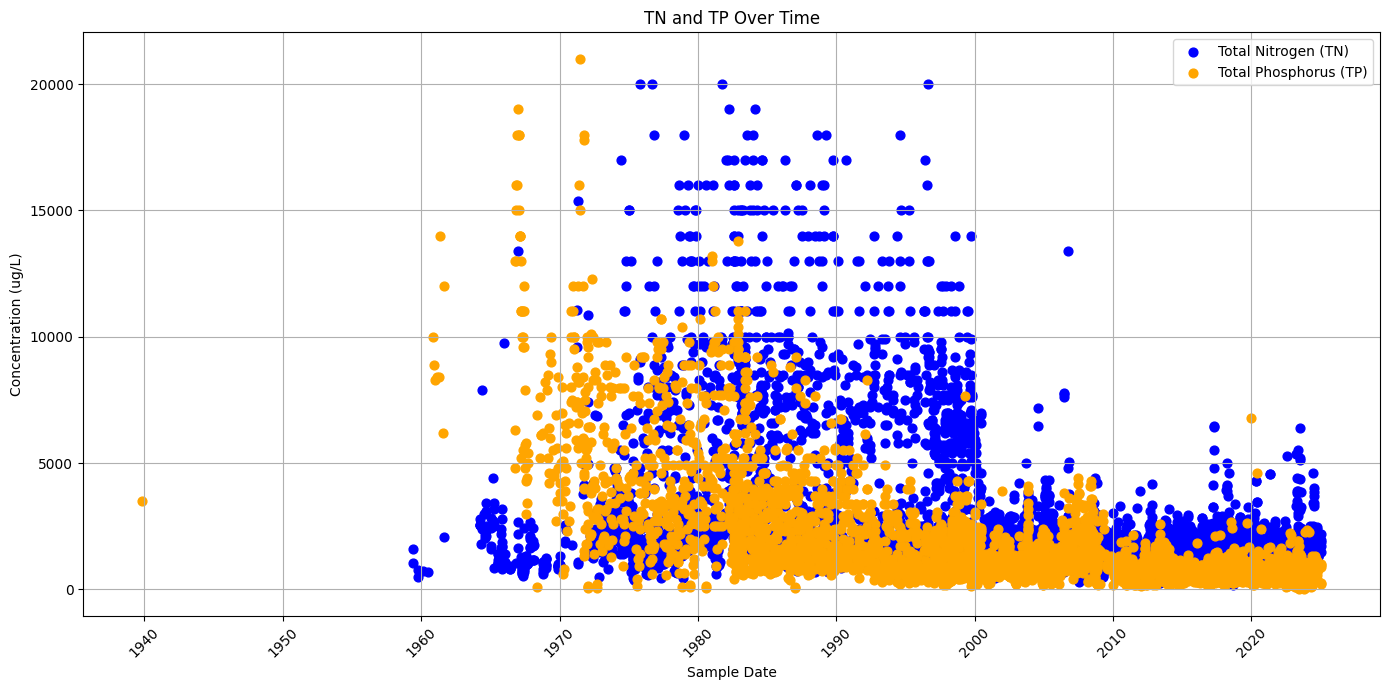

In [6]:
# Read the file (adjust path if needed)
file_path = f'input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Convert SampleDate to datetime and drop invalid dates
df['SampleDate'] = pd.to_datetime(df['SampleDate'], errors='coerce')
df = df.dropna(subset=['SampleDate'])
display(df)

# Filter TN and TP data
tn_data = df[df['Parameter'] == 'TN_ugl']
tp_data = df[df['Parameter'] == 'TP_ugl']

# Sort by SampleDate
tn_data = tn_data.sort_values(by='SampleDate')
tp_data = tp_data.sort_values(by='SampleDate')

# Plot TN and TP as points
plt.figure(figsize=(14, 7))
plt.scatter(tn_data['SampleDate'], tn_data['Result_Value'], label='Total Nitrogen (TN)', color='blue', s=40)
plt.scatter(tp_data['SampleDate'], tp_data['Result_Value'], label='Total Phosphorus (TP)', color='orange', s=40)

# Add labels and title
plt.xlabel('Sample Date')
plt.ylabel('Concentration (ug/L)')
plt.title('TN and TP Over Time')

# Add legend
plt.legend()

# Improve formatting
plt.xticks(rotation=45)
plt.grid(True)

# Adjust spacing between subplots
plt.tight_layout()

plt.savefig(f'figures/{river}_river_Fig3_TN_TP_all_data.png')

# Show plot
plt.show()

In [7]:
display(df['DataSource'].unique())
display(len(df['DataSource'].unique()))
display(len(df['StationID'].unique()))


array(['WIN_21FLGW', 'WIN_21FLSWFD', 'STORET_FLPRMRWS', 'WIN_21FLWQA',
       'POLKCO_NRD_WQ', 'STORET_21FLPOLK', 'STORET_21FLTPA',
       'WIN_21FLFTM', 'LEGACYSTORET_21FLSWFD', 'LEGACYSTORET_21FLA',
       'USGS_NWIS', 'WIN_21FLTPA', 'STORET_21FLSWFD', 'WIN_FLPRMRWS',
       'STORET_21FLWQSP', 'STORET_21FLGW', 'WIN_21FLMOSA',
       'STORET_21FLFTM', 'LEGACYSTORET_1113S000', 'LAKEWATCH_V',
       'WIN_21FLPOLK', 'LEGACYSTORET_21FLGW  ', 'STORET_SWFMDDEP',
       'WIN_21FLCHCO'], dtype=object)

24

377

### 2.2 Select stations at lower reach

,StationID,WBodyID,WaterBodyName,DataSource,StationName,Actual_Latitude,Actual_Longitude,TN_Samples,TP_Samples,StartDate,EndDate
6,02296750,181964,Peace River,USGS_NWIS,PEACE RIVER AT ARCADIA FL,27.222271,-81.875917,155,147,1990-03-21,2004-09-29
7,02297330,181964,Peace River,USGS_NWIS,PEACE RIVER AT FT. OGDEN FL,27.088388,-81.993976,161,156,1996-08-26,2000-06-27
58,270318081593100,181964,Peace River,USGS_NWIS,PEACE RIVER AT RIVER MILE 14.82 NEAR FT. OGDE...,27.055334,-81.991753,163,170,1996-08-26,2000-06-27
97,3556,181964,Peace River,WIN_21FLGW,PEACE RIVER,27.221164,-81.876377,291,291,1998-10-08,2024-11-05
340,PR14,181964,Peace River,STORET_FLPRMRWS,Peace River south of Desoto Marina,27.056200,-81.992215,496,181,1996-08-26,2022-12-21
341,PR18,181964,Peace River,STORET_FLPRMRWS,Peace River N of SR761,27.089117,-81.992443,723,452,1996-08-26,2022-12-21


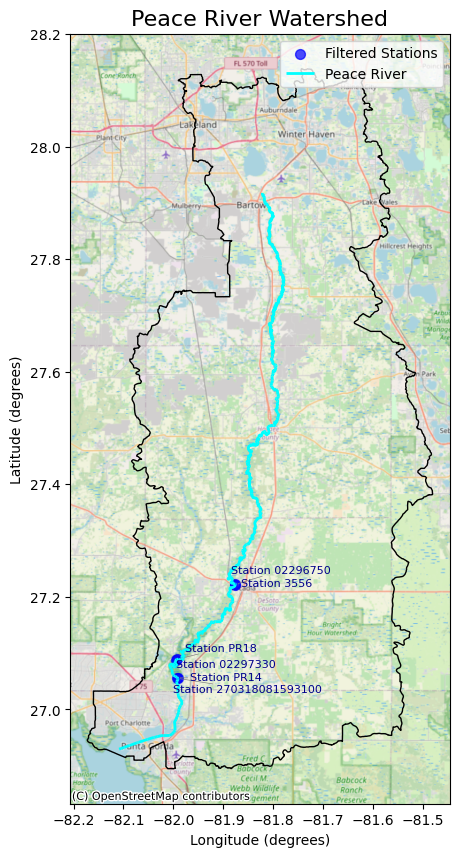

Total Number of Stations: 6
Total Number of Samples: 3386
Total Number of TN Samples: 1989
Total Number of TP Samples: 1397
Sampling Start Date: 1990-03-21 00:00:00
Sampling End Date: 2024-11-05 00:00:00


,WBodyID,DataSource,StationName,StationID,TN_Samples,TP_Samples
6,181964,USGS_NWIS,PEACE RIVER AT ARCADIA FL,02296750,155,147
7,181964,USGS_NWIS,PEACE RIVER AT FT. OGDEN FL,02297330,161,156
58,181964,USGS_NWIS,PEACE RIVER AT RIVER MILE 14.82 NEAR FT. OGDE...,270318081593100,163,170
97,181964,WIN_21FLGW,PEACE RIVER,3556,291,291
340,181964,STORET_FLPRMRWS,Peace River south of Desoto Marina,PR14,496,181
341,181964,STORET_FLPRMRWS,Peace River N of SR761,PR18,723,452


In [8]:
# Load the data
file_path = f'input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
data = pd.read_csv(file_path)

# Convert coordinates to float64 to maintain precision
data['Actual_Latitude'] = data['Actual_Latitude'].astype('float64')
data['Actual_Longitude'] = data['Actual_Longitude'].astype('float64')

# Drop rows with missing coordinates
data = data.dropna(subset=['Actual_Latitude', 'Actual_Longitude'])

# Filter out data before 1990
data['SampleDate'] = pd.to_datetime(data['SampleDate'])
data = data[data['SampleDate'].dt.year >= 1990]

# Create a summary table for each station
summary = data.groupby('StationID').agg(
    WBodyID=('WBodyID', 'first'),
    WaterBodyName=('WaterBodyName', 'first'),
    DataSource=('DataSource', 'first'),
    StationName=('StationName', 'first'),
    Actual_Latitude=('Actual_Latitude', 'first'),
    Actual_Longitude=('Actual_Longitude', 'first'),
    TN_Samples=('Parameter', lambda x: (x == 'TN_mgl').sum() + (x == 'TN_ugl').sum()),
    TP_Samples=('Parameter', lambda x: (x == 'TP_mgl').sum() + (x == 'TP_ugl').sum()),
    StartDate=('SampleDate', 'min'),
    EndDate=('SampleDate', 'max')
).reset_index()

# Filter stations that have 10 or more sample points for either TN or TP
stations_with_10_or_more_samples = summary[
    (summary['TN_Samples'] >= 30) | (summary['TP_Samples'] >= 30)
]

# Remove stations above latitude 27.4 to keep only Gulf-proximate stations
stations_with_10_or_more_samples = stations_with_10_or_more_samples[
    stations_with_10_or_more_samples['Actual_Latitude'] <= 27.4
]
display(stations_with_10_or_more_samples)

# Convert to GeoDataFrame
filtered_gdf = gpd.GeoDataFrame(
    stations_with_10_or_more_samples,
    geometry=[Point(xy) for xy in zip(
        stations_with_10_or_more_samples['Actual_Longitude'],
        stations_with_10_or_more_samples['Actual_Latitude']
    )],
    crs='EPSG:4326'
)

# Load Peace River Watershed shapefile
path = f'input/NHD_H_{basinID}_HU8_Shape'
watershed = gpd.read_file(f'{path}/WBDHU8.shp').to_crs(epsg=4326)

# Load Peace River flowline data
flowlines = gpd.read_file(f'{path}/NHDFlowline.shp').to_crs(epsg=4326)

# Filter for Peace River flowline
peace_river = flowlines[flowlines['gnis_name'].str.strip().str.lower() == 'peace river']

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Plot watershed boundary
watershed.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Watershed Boundary')

# Plot filtered stations
filtered_gdf.plot(ax=ax, markersize=50, color='blue', label='Filtered Stations', alpha=0.7)

# Plot Peace River
peace_river.plot(ax=ax, color='cyan', label=f'{river} River', linewidth=2)

# Add station labels using adjustText to avoid overlap
texts = []
for x, y, label in zip(
    filtered_gdf.geometry.x, 
    filtered_gdf.geometry.y, 
    filtered_gdf['StationID']
):
    texts.append(ax.text(x, y, f'Station {label}', fontsize=8, ha='left', va='bottom', color='darkblue'))

# Automatically adjust text to prevent overlap
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Add basemap without changing CRS
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:4326')

# Fix axis labels to show degrees (latitude and longitude)
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Latitude (degrees)')

# Customize plot
plt.title(f'{river} River Watershed', fontsize=16)
plt.legend()

# Save and show plot
plt.savefig(f'figures/{river}_river_Fig4_TN_TP_stations_map.png', dpi=300)
plt.show()

# Total number of stations after filtering
total_stations = len(stations_with_10_or_more_samples)

# Total number of samples (sum of TN and TP samples)
total_samples = stations_with_10_or_more_samples['TN_Samples'].sum() + stations_with_10_or_more_samples['TP_Samples'].sum()

# Total number of TN and TP samples
total_tn_samples = stations_with_10_or_more_samples['TN_Samples'].sum()
total_tp_samples = stations_with_10_or_more_samples['TP_Samples'].sum()

# Sampling start and end date
sampling_start_date = stations_with_10_or_more_samples['StartDate'].min()
sampling_end_date = stations_with_10_or_more_samples['EndDate'].max()

# Print the results
print(f"Total Number of Stations: {total_stations}")
print(f"Total Number of Samples: {total_samples}")
print(f"Total Number of TN Samples: {total_tn_samples}")
print(f"Total Number of TP Samples: {total_tp_samples}")
print(f"Sampling Start Date: {sampling_start_date}")
print(f"Sampling End Date: {sampling_end_date}")



# Select the relevant columns
df_to_export = stations_with_10_or_more_samples[['WBodyID', 'DataSource', 'StationName', 'StationID', 'TN_Samples', 'TP_Samples']]
display(df_to_export)
df_to_export.to_csv('output/stations_with_10_or_more_samples.csv', index=False)

        

### 2.3 Plot statios at lower reach with more than 30 samples

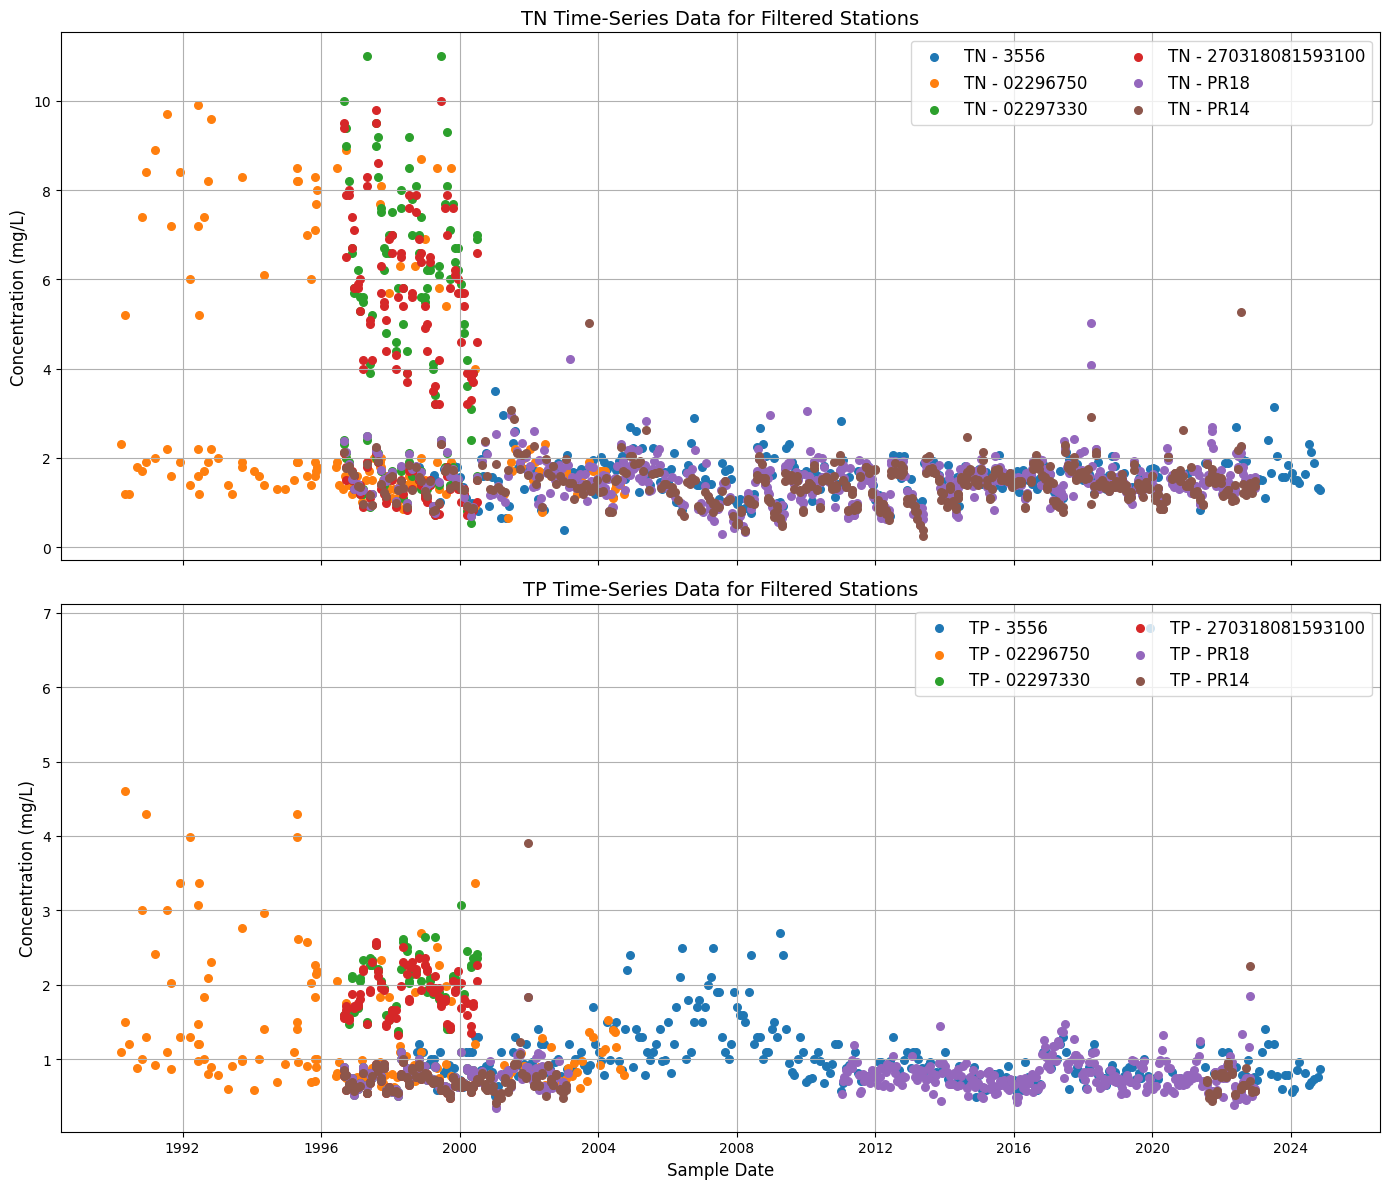

In [9]:
# Load the data
file_path = f'input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
data = pd.read_csv(file_path)

# Convert coordinates to float64 to maintain precision
data['Actual_Latitude'] = data['Actual_Latitude'].astype('float64')
data['Actual_Longitude'] = data['Actual_Longitude'].astype('float64')

# Drop rows with missing coordinates
data = data.dropna(subset=['Actual_Latitude', 'Actual_Longitude'])

# Filter out data before 1990
data['SampleDate'] = pd.to_datetime(data['SampleDate'])
data = data[data['SampleDate'].dt.year >= 1990]

# Create a summary table for each station
summary = data.groupby('StationID').agg(
    WBodyID=('WBodyID', 'first'),
    WaterBodyName=('WaterBodyName', 'first'),
    DataSource=('DataSource', 'first'),
    StationName=('StationName', 'first'),
    Actual_Latitude=('Actual_Latitude', 'first'),
    Actual_Longitude=('Actual_Longitude', 'first'),
    TN_Samples=('Parameter', lambda x: (x == 'TN_mgl').sum() + (x == 'TN_ugl').sum()),
    TP_Samples=('Parameter', lambda x: (x == 'TP_mgl').sum() + (x == 'TP_ugl').sum()),
    StartDate=('SampleDate', 'min'),
    EndDate=('SampleDate', 'max')
).reset_index()

# Filter stations that have 30 or more sample points for either TN or TP
filtered_stations = summary[
    (summary['TN_Samples'] >= 30) | (summary['TP_Samples'] >= 30)
]

# Remove stations above latitude 27.4 (keep Gulf-proximate stations)
filtered_stations = filtered_stations[filtered_stations['Actual_Latitude'] <= 27.4]

# Keep only data from filtered stations
filtered_data = data[data['StationID'].isin(filtered_stations['StationID'])]

# Separate TN and TP data
tn_data = filtered_data[filtered_data['Parameter'].isin(['TN_mgl', 'TN_ugl'])]
tp_data = filtered_data[filtered_data['Parameter'].isin(['TP_mgl', 'TP_ugl'])]

# Convert concentration to consistent units (mg/L) if necessary
tn_data.loc[tn_data['Parameter'] == 'TN_ugl', 'Result_Value'] /= 1000
tp_data.loc[tp_data['Parameter'] == 'TP_ugl', 'Result_Value'] /= 1000

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

# Plot TN in the first subplot with lines and markers
Line= False 
for station_id in tn_data['StationID'].unique():
    station_data = tn_data[tn_data['StationID'] == station_id]
    if Line:
        axes[0].plot(station_data['SampleDate'], station_data['Result_Value'], marker='o', label=f'TN - {station_data["StationID"].iloc[0]}')
    else:
        axes[0].scatter(station_data['SampleDate'], station_data['Result_Value'], label=f'TN - {station_data["StationID"].iloc[0]}', s=30)

# Customize TN plot
axes[0].set_title('TN Time-Series Data for Filtered Stations', fontsize=14)
axes[0].set_ylabel('Concentration (mg/L)', fontsize=12)
axes[0].legend(fontsize=12, loc='upper right', ncol=2)
axes[0].grid(True)

# Plot TP in the second subplot as dots
for station_id in tp_data['StationID'].unique():
    station_data = tp_data[tp_data['StationID'] == station_id]
    if Line:
        axes[1].plot(station_data['SampleDate'], station_data['Result_Value'], marker='o', label=f'TP - {station_data["StationID"].iloc[0]}')
    else:
        axes[1].scatter(station_data['SampleDate'], station_data['Result_Value'], label=f'TP - {station_data["StationID"].iloc[0]}', s=30)
    


# Customize TP plot
axes[1].set_title('TP Time-Series Data for Filtered Stations', fontsize=14)
axes[1].set_xlabel('Sample Date', fontsize=12)
axes[1].set_ylabel('Concentration (mg/L)', fontsize=12)
axes[1].legend(fontsize=12, loc='upper right', ncol=2)
axes[1].grid(True)

# Adjust spacing between subplots
plt.tight_layout()

# Save and show plot
plt.savefig(f'figures/{river}_river_Fig5_TN_TP_data_selected.png', dpi=300)
plt.show()


### 2.4 Summary of stations of TN and TP data from 1990

In [10]:
# Load the data
file_path = f'input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
data = pd.read_csv(file_path)

# Clean data by stripping whitespace and converting to lowercase
data['Parameter'] = data['Parameter'].str.strip().str.lower()

# Convert SampleDate to datetime format
data['SampleDate'] = pd.to_datetime(data['SampleDate'], errors='coerce')

# Remove data prior to 1990
data = data[data['SampleDate'] >= '1990-01-01']

# Create a summary DataFrame for each unique StationID
summary = data.groupby('StationID').agg(
    WBodyID=('WBodyID', 'first'),
    WaterBodyName=('WaterBodyName', 'first'),
    DataSource=('DataSource', 'first'),
    StationName=('StationName', 'first'),
    Actual_StationID=('Actual_StationID', 'first'),
    Actual_Latitude=('Actual_Latitude', 'first'),
    Actual_Longitude=('Actual_Longitude', 'first'),
    TN_Samples=('Parameter', lambda x: x.str.contains('tn').sum()),  # Count all TN entries
    TP_Samples=('Parameter', lambda x: x.str.contains('tp').sum()),  # Count all TP entries
    Start_Date=('SampleDate', 'min'),
    End_Date=('SampleDate', 'max')
).reset_index()

# Sort by Latitude (descending) and Longitude (ascending)
summary = summary.sort_values(by=['Actual_Latitude', 'Actual_Longitude'], ascending=[False, True])

# Display the summary DataFrame
display(summary)

# Save to CSV (if needed)
summary.to_csv(f'output/{river}_TN_TP_sations_summary.csv', index=False)

,StationID,WBodyID,WaterBodyName,DataSource,StationName,Actual_StationID,Actual_Latitude,Actual_Longitude,TN_Samples,TP_Samples,Start_Date,End_Date
77,29887,181964,Peace River,STORET_21FLGW,SW3-LR-2007 PEACE RIVER,29887,27.914571,-81.820521,1,1,2006-06-27,2006-06-27
122,51426,181964,Peace River,STORET_21FLGW,Z4-LR-11010 PEACE RIVER,51426,27.912942,-81.820375,1,1,2017-05-16,2017-05-16
40,24833,181964,Peace River,STORET_21FLSWFD,PEACE RIVER @ BARTOW,24833,27.902373,-81.817604,312,306,1997-08-04,2024-03-06
0,02294650,181964,Peace River,USGS_NWIS,PEACE RIVER AT BARTOW FL,02294650,27.902248,-81.817304,105,105,1990-02-08,1999-09-23
47,25020044,181964,Peace River,STORET_21FLTPA,TP18 - PEACE RIVER,25020044,27.901944,-81.817528,9,9,2008-02-04,2008-11-03
...,...,...,...,...,...,...,...,...,...,...,...,...
321,PR103_0522,181964,Peace River,WIN_FLPRMRWS,Peace River @ river kilometer 19 @ 12 ppt iso...,PR103_0522,27.016333,-81.984389,1,1,2022-05-10,2022-05-10
142,CH-029,181964,Peace River,STORET_SWFMDDEP,CHARLOTTE HARBOR PEACE RIVER @ 2ND POWER LINES,CH-029,27.016333,-81.984167,19,22,1998-03-26,2000-12-13
143,CH-029,181964,Peace River,LEGACYSTORET_21FLSWFD,CHARLOTTE HARBOR PEACE RIVER @ 2ND POWER LINE...,CH-029,27.016333,-81.984167,27,0,1996-01-22,1998-08-11
289,PR102_0320,181964,Peace River,WIN_FLPRMRWS,Peace River @ river kilometer 19 @ 6 ppt isoh...,PR102_0320,27.016111,-81.985083,1,0,2020-03-10,2020-03-10


### 2.5 Pre-process TN and TP data 

In [11]:
# Read the data
file_path = f'input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Pivot the Result_Value based on the Parameter column
df['TP'] = df.loc[df['Parameter'] == 'TP_ugl', 'Result_Value']
df['TN'] = df.loc[df['Parameter'] == 'TN_ugl', 'Result_Value']

# Keep only required columns
df = df[['WBodyID', 'WaterBodyName', 'DataSource', 'StationID', 'StationName',
         'Actual_Latitude', 'Actual_Longitude', 'SampleDate', 'TP', 'TN', 'QACode', 'Result_Comment']]

# Rename latitude and longitude columns
df.rename(columns={'Actual_Latitude': 'Latitude', 'Actual_Longitude': 'Longitude'}, inplace=True)

# Convert SampleDate to datetime
df['SampleDate'] = pd.to_datetime(df['SampleDate'], errors='coerce')

# Set SampleDate as the index and sort from oldest to newest
df.set_index('SampleDate', inplace=True)
df.sort_index(ascending=True, inplace=True)

# Save to new CSV
df.to_csv(f'output/{river}_TN_TP_data_all.csv', index=True)

# Display the cleaned dataframe
display(df)

# Show unique values for specified columns
unique_wbodyid = df['WBodyID'].unique()
unique_waterbodyname = df['WaterBodyName'].unique()
unique_datasource = df['DataSource'].unique()
unique_qacode = df['QACode'].unique()

# Display the unique values
print("Unique WBodyID values:")
print(unique_wbodyid)

print("\nUnique WaterBodyName values:")
print(unique_waterbodyname)

print("\nUnique DataSource values:")
print(unique_datasource)

print("\nUnique QACode values:")
print(unique_qacode)

,WBodyID,WaterBodyName,DataSource,StationID,StationName,Latitude,Longitude,TP,TN,QACode,Result_Comment
SampleDate,,,,,,,,,,,
1939-10-31,181964,Peace River,USGS_NWIS,02296750,PEACE RIVER AT ARCADIA FL,27.222271,-81.875917,3500.0,NaN,NaN,NaN
1959-05-27,181964,Peace River,LEGACYSTORET_21FLA,25020006,PEACE RIVER BR FLA HWY 64A / SOUTH-EAST / PEACE,27.540000,-81.792500,NaN,1580.0,NaN,FCCDR Calculated
1959-05-27,181964,Peace River,LEGACYSTORET_21FLA,25020008,PEACE RIVER BR FLA HWY |664 / SOUTH-EAST / PEACE,27.645556,-81.802500,NaN,1025.0,NaN,FCCDR Calculated
1959-10-20,181964,Peace River,LEGACYSTORET_21FLA,25020003,PEACE RIVER BR FLA HWY #760 / SOUTH-EAST / PEACE,27.161944,-81.901944,NaN,746.0,NaN,FCCDR Calculated
1959-10-20,181964,Peace River,LEGACYSTORET_21FLA,25020004,PEACE RIVER BR FLA HWY #70 / SOUTHEAST / PEAC...,27.221944,-81.876389,NaN,502.0,NaN,FCCDR Calculated
...,...,...,...,...,...,...,...,...,...,...,...
2025-01-09,181964,Peace River,WIN_21FLPOLK,PEACE RVR5 - PISGAH,Peace Rvr5 - Pisgah,27.722774,-81.790078,874.0,NaN,NaN,NaN
2025-01-09,181964,Peace River,WIN_21FLPOLK,PEACE RVR78 - CO LINE,Peace Rvr78 - Co Line,27.646111,-81.802278,NaN,1879.0,NaN,Water Institute Calculated: TKN + NO3
2025-01-09,181964,Peace River,WIN_21FLPOLK,PEACE RVR78 - CO LINE,Peace Rvr78 - Co Line,27.646111,-81.802278,970.0,NaN,J,J6=matrix spike recovery outside acceptable li...


Unique WBodyID values:
[ 181964  300031  300106  300115 2003656   -9999 9000307]

Unique WaterBodyName values:
['Peace River' 'Hunter Creek' 'Barber Branch' 'Arcadia Canal'
 'Camp Branch' 'Weather, Rainfall, Ground Water'
 'Peace River Estuary (Upper Segment North)']

Unique DataSource values:
['USGS_NWIS' 'LEGACYSTORET_21FLA' 'LEGACYSTORET_1113S000'
 'LEGACYSTORET_21FLSWFD' 'STORET_21FLPOLK' 'POLKCO_NRD_WQ'
 'STORET_FLPRMRWS' 'STORET_21FLSWFD' 'LEGACYSTORET_21FLGW  '
 'STORET_SWFMDDEP' 'STORET_21FLGW' 'STORET_21FLFTM' 'STORET_21FLTPA'
 'LAKEWATCH_V' 'WIN_21FLMOSA' 'STORET_21FLWQSP' 'WIN_21FLSWFD'
 'WIN_FLPRMRWS' 'WIN_21FLTPA' 'WIN_21FLWQA' 'WIN_21FLGW' 'WIN_21FLPOLK'
 'WIN_21FLFTM' 'WIN_21FLCHCO']

Unique QACode values:
[nan 'E' '<' 'A' 'J' 'Q' '+' 'Q+' 'Y' 'Y+' 'QY' 'V' 'AJ' 'U']


Caloosahatchee River Basin   https://chnep.wateratlas.usf.edu/waterbodies/basins/1/caloosahatchee-river-basin